# Minimum X-MACE Autoencoder Training Example

This notebook trains a tiny `AutoencoderExcitedMACE` model directly from the installed `mace` package. It assumes the current working directory contains `SINGLET_SOC_ALL.xyz`, and it saves all generated files back into this same directory. 

The tutorials in the original github were more intended for use from the Command Line Interface (CLI), meaning it takes in the model arguments as flags from the main file, then runs the script (found under mace/cli/run_train.py). That file is a super "generalised" script that takes every possible input combination and helps you run it, so its convenient for quick use and reproducing results. However, if you want to learn the different parts of the repository or customise the model etc its probably easier and more intuitive to use the classes directly. 

In [1]:
import os
import json
import time
"""
The notebook assumes it is launched from the directory containing SINGLET_SOC_ALL.xyz.
It should be the case as long as this notebook is in the same folder as the xyz file
Alternatively, you can mantually set the XYZ_FILE path to the correct location
"""

ROOT_PATH = os.getcwd()
XYZ_FILE = os.path.join(ROOT_PATH, "../data/A01_ethene_grid_static_CASSCF.xyz")

# All outputs will be saved in this folder called RUN_DIR
RUN_DIR = os.path.join(ROOT_PATH, "trial_run_output")
# Creates the folder RUN_DIR, if it exist already, it will not raise error
os.makedirs(RUN_DIR, exist_ok=True)

# NumPy is used for small array inspections and simple mean/MAE calculations.
import numpy as np

# ASE reads the extended XYZ trajectory into a list of Atoms objects.
import ase.io

# PyTorch handles the model, autograd, optimizer, and checkpoint saving.
import torch

# e3nn irreps describe equivariant feature types used by MACE layers.
# This is your spherical harmonics that makes the model equivariant 
from e3nn import o3

# Import X-MACE/MACE from the active conda environment.
# No local source-code path is inserted here.
from mace import data, modules, tools
from mace.tools import torch_geometric

# CPU default for mac. Change to cuda or mps later if available.
DEVICE = torch.device("cpu")

print("ROOT_PATH:", ROOT_PATH)
print("XYZ_FILE:", XYZ_FILE)
print("RUN_DIR:", RUN_DIR)
print("DEVICE:", DEVICE)

ROOT_PATH: /home/yutong/X-MACE/tutorials
XYZ_FILE: /home/yutong/X-MACE/tutorials/../data/A01_ethene_grid_static_CASSCF.xyz
RUN_DIR: /home/yutong/X-MACE/tutorials/trial_run_output
DEVICE: cpu


## 1. Load Dataset

The fake tutorial uses the same dataset as the one found in the original tutorial. So here there are 50 geometries of 1 molecules with 23 Hydrogens. The molecule coordinates and info (energies / forces etc) are found in the extended xyz file.

In [3]:
"""
N_GEOMETRIES is the number of geometries to includes from the extended XYZ file 
Total there are 50 geometries in the SINGLET_SOC_ALL.xyz file. If it gets too 
laggy or slow, can cut down the number of geometries. But so far 50 seems to work
fine? Because we can tune the model to be smaller.
"""
N_GEOMETRIES = 5

# ASE reads only the first N_GEOMETRIES frames from the extended XYZ file.
# ASE is a library (atomic simulation environment) that can read and write 
# many file formats, including extended XYZ.
# This creates a list of ASE Atoms objects
atoms_list = ase.io.read(XYZ_FILE, index=f":{N_GEOMETRIES}")

# Example_atoms is an ASE Atoms object that has various attributes 
# You can access the ATOM attributes like position, chemical formula etc 
# by doing example_atoms.get_positions(), example_atoms.get_chemical_formula() etc
example_atoms = atoms_list[0]

# These are the reference quantities stored in atoms.info for this dataset.
target_keys = ["REF_energy", "REF_forces"]

print("Loaded geometries:", len(atoms_list))
print("Atoms per geometry:", len(example_atoms))
# This part gets the atom formula, a beautiful H23
print("Formula:", example_atoms.get_chemical_formula())

# Prints the different reference quantities and their shapes
for key in target_keys:
    print(f"{key:16s} shape={np.asarray(example_atoms.info[key]).shape}")

Loaded geometries: 5
Atoms per geometry: 6
Formula: C2H4
REF_energy       shape=(1, 3)
REF_forces       shape=(6, 3, 3)


Briefly, the above quantities are the labels for each configuration. They can be used to train the model (predict it), or be part of the loss function. 

1. Energy: 
- Energy of the particular configuration. From quantum chemistry this is just calculated with the electronic hamiltonian with various degrees of approximation. More approximation = faster but less accurate. 

- The shape is 1 by 4 because there are 4 electronic state energies for each configuration. (Ground state, first second and third excited state). At least this is what we care about.

2. Forces: 
- They are 3D vectors that acts on each atom. So every atom has a force acting on it. This force is calculated by taking derivative of the energy wrt to the atom positions. 

- If you get this by finite difference (slightly shift each atom dx dy dz around in space and measure and calculate energy then gradients), its very slow. 

- If you have analytical gradients defined then its way faster (basically from the QC iteration and formula and quick math --> derive a formula for the derivative), its a lot faster. Somehow with quick maths it can be done, but not all softwares have it. 

- For neural networks, forces become super easy to calculate because we can just use auto diff, ie chain rule everything backwards to find the gradients (usually done in reverse mode I think). Because each layer in a neural network is a math function, its very easy to do auto diff and get the forces for free.

- Shape is 23 by 4 by 3 because each atom has a force (23 atoms total), there are 4 excited states, and 3 dimensions (Fx Fy Fz). 

3. The others
- Smooth NAC stands for Non Adiabatic Couplings (how much nuclear motion couples different states). It is only relevant when you want to have some dynamic simulations for certain applications, then you care about how the coupling is like when nucleus move (I think). Without it energies and forces can get you a lot of things already

- SOCs are Spin-Orbit Couplings. This is a quantum effect that only affects certain molecules (more with heavy atoms etc). So for most intents and purposes it can be ignored because the effective is quite weak also. The effect should be approximately neglible in the dataset. Unless you want to do things like study OLED emitters then you need to consider spin orbital coupling effects 

- Pretty sure can ignore NACs and SOCs, only forces and energies relevant.

## 2. Convert ASE Objects Into MACE Graph Data

MACE does not train directly on ASE objects. It converts each geometry into a graph with atom features, neighbor edges, positions, and labels.

A graph is just a different representation of the molecule that the model can read.
It consist of nodes (atoms) and edges (bonds) that represents the molecule. Each node and edge is basically just some vector. During the GNN training, they will "gossip" with each other and information passes between each other from the nodes and connected edges which lets the graph "learn" who is beside them.

In [4]:
# Convert ASE Atoms into MACE Configuration objects.
# This uses the MACE DATA class to do the conversion.
configs = data.config_from_atoms_list(
    atoms_list,
    energy_key="REF_energy",
    forces_key="REF_forces",
    nacs_key="REF_smooth_nacs",
    socs_key="REF_socs",
    config_type_weights={"Default": 1.0},
)


In [5]:
# Cutoff radius for graph edges, in Angstrom.
# This means if you are within 5 Angstrom from each other then you are counted 
# as having a "bond". Having a "bond" will be represnted as an edge in the graph
R_MAX = 5.0

# Batch size is just how many geometries you process at once. For this case 
# we have total 50 geometries, so if we set batch size to 10, then we will put in 10
# geometries at once, and then the next 10 geometries, and so on. In the actual 
# training, probably will have thousands of data, so each "epoch" will have many many
# batches. Batch size here is kept low to keep RAM low

BATCH_SIZE = 4

# This is the percentage of the dataset that will be used for validation 
# meaning 20% of the 50 geometries will be hidden from the model during training
# to see how well it can generalise the learning. 
VALID_FRACTION = 0.2

# Split into train and validation lists. This also writes valid_indices_123.txt in RUN_DIR.
train_configs, valid_configs = data.random_train_valid_split(
    configs,
    valid_fraction=VALID_FRACTION,
    seed=123,
    work_dir=RUN_DIR,
)

In [6]:

# z_table maps atomic numbers to compact one-hot indices used by MACE.
# Basically because the network cannot read H C O N etc, so instead we convert
# Each of them into a vector based on atomic number. This "mapping" to conver it
# into a vector is "pre learned" when they built this. 
z_table = tools.get_atomic_number_table_from_zs(
    z for config in (train_configs + valid_configs) for z in config.atomic_numbers
)

In [7]:
# This dataset does not provide isolated atomic energies, so estimate E0 values
# from the tiny training subset. For real work, prefer physically meaningful E0s.
atomic_energies_dict = data.compute_average_E0s(train_configs, z_table)
atomic_energies = np.array([atomic_energies_dict[z] for z in z_table.zs], dtype=np.float64)

# Quick check: MACE expects one baseline energy per element in z_table.
print("Atomic energies array:", atomic_energies)


Atomic energies array: [-422.9311256 -211.4655628]


This part on atomic energies we are just trying to provide a baseline for the model
to guess from. So eg the actual energy is 10000.12345. We can tell the model that 
the energy is about 10000, so the model will just have to learn how to get the 0.12345
correction. This is just to make the model easier to train and converge faster if not
the optimiser will have a hard time. 

This 10000 value can be obtained from various means. Ie practically we can calculate
the energies of individual isolated atoms for example, and use that as a start. Since
most of the energies will be around that value, but we are interested in the fine tune
chemically accurate values.

For this example specifically, we use the data class function compute_average_E0s 
to get the average energy of the training set as a baseline. Which means we take the
average of all the 50 geometries and average it, then say this is a good start point. 
Then our model is trying to learn how to accurately start from there and predict the
exact energy for each geometry. 

This variable atomic_energies is used later when initialising the model. Currently there is only one energy cause our molecules only got H. 

In [8]:
# Note the usage of the class Mace.Data 
# Convert Configuration objects into AtomicData graph objects.
# Each AtomicData object contains edges, shifts, positions, labels, and atom features.
train_set = [
    data.AtomicData.from_config(config, z_table=z_table, cutoff=R_MAX)
    for config in train_configs
]
valid_set = [
    data.AtomicData.from_config(config, z_table=z_table, cutoff=R_MAX)
    for config in valid_configs
]
"""
The top part is just using the functions from Mace.Data to convert the ASE atoms
into vectors from the z_table, such that they can be processed by the network.

The bottom part uses pytorch dataloader, which is a different class. This class 
is used to manage the data for training and validation for the neural network. 
These two variables train_loader and valid_loader are the dataloader objects that 
will help to manage all the data. 
Its almost like storing it in a list, but a lot more efficient memory wise because
of the backend. Basically it will let you store thousands of geometries without 
RAM exploding (if you just use a normal list it will die).
"""
# DataLoader collates several molecular graphs into one batched graph.
train_loader = torch_geometric.dataloader.DataLoader(
    train_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)
valid_loader = torch_geometric.dataloader.DataLoader(
    valid_set, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

# MACE normalizes messages by the average neighbor count.
avg_num_neighbors = modules.compute_avg_num_neighbors(train_loader)
# Used later on during training 

print("Training geometries:", len(train_configs))
print("Validation geometries:", len(valid_configs))
print("Atomic numbers:", [int(z) for z in z_table.zs])
print("Estimated atomic energies:", {int(k): float(v) for k, v in atomic_energies_dict.items()})
print("Average neighbors:", float(avg_num_neighbors))

Training geometries: 4
Validation geometries: 1
Atomic numbers: [1, 6]
Estimated atomic energies: {1: -422.93112559898066, 6: -211.46556279949033}
Average neighbors: 5.0


## 3. Build A Tiny AutoencoderExcitedMACE Model

This is the X-MACE-style autoencoder model. 

Not too sure 100% on the full architecture yet say real but roughly its a Graph neural network --> auto encoder (basically learning a lower dimensional latent space) --> learns a companion matrix --> gets the energies. 

The settings below are intentionally small so the example stays safe on an 8 GB RAM machine. Can probably play around with it to see what it does, but only sosme of them kinda understand what it does. 

In [15]:
# Build the model directly. 
# Say real idk wtf all the parameters are but roughly can guess a few 
# For those that differed from the original defaults I included the default value 
# If got workstation can try increase the value to default and see what happens


model = modules.AutoencoderExcitedMACE(
    r_max=R_MAX,  # default = 5.0 (this the cut off bond length defined above)
    num_bessel=4,  # default = 8
    num_polynomial_cutoff=3,  # default = 5
    num_permutational_invariant=4,  # default = 16 (Dimensions of latent space)
    n_energies=3,  #  This is the number of excited states you want to predict.
    # 4 means ground state + 3 excited states. 
    max_ell=2,  # default = 3 (This should be your spherical harmonics l value)
    interaction_cls=modules.interaction_classes["RealAgnosticResidualInteractionBlock"], 
    interaction_cls_first=modules.interaction_classes["RealAgnosticResidualInteractionBlock"], 
    num_interactions=1,  # default = 2 (number of message-passing layers/iterations)
    num_elements=len(z_table),  
    hidden_irreps=o3.Irreps("4x0e + 4x1o"),  # default = None
    MLP_irreps=o3.Irreps("4x0e"),  # default = "16x0e"
    atomic_energies=atomic_energies,  
    avg_num_neighbors=float(avg_num_neighbors),  
    atomic_numbers=[int(z) for z in z_table.zs],  
    correlation=1,  # default = 3
    gate=modules.gate_dict["silu"],  
    radial_MLP=[32, 32],  # default = "[64, 64, 64]"
    # I think these few is if you want NAC or SOC (which is not useful for this proj)
    compute_nacs=False,  # default = False
    compute_socs=False,  # default = False
    nac_num=0,  # default = None
    soc_num=0,  # default = None
).to(DEVICE)


/home/yutong/micromamba/envs/x-mace-env/lib/python3.13/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
/home/yutong/micromamba/envs/x-mace-env/lib/python3.13/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
/home/yutong/micromamba/envs/x-mace-env/lib/python3.13/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute

In [16]:
# AutoencoderExcitedMACE uses this invariant-aware loss.
# NAC/SOC/dipole terms are set to zero for the minimal example.
# The energy and forces weights are set to the default values, can explore 
# changing it. 
loss_fn = modules.InvariantsWeightedEnergyForcesNacsDipoleLoss(
    energy_weight=1.0,
    forces_weight=5.0,
    dipoles_weight=0.0,
    nacs_weight=0.0,
    socs_weight=0.0,
)

# Adam the goat 
# Is just a simple and popular optimiser (algorithm for deciding how to update
# the weights of the neural network)
optimizer = torch.optim.Adam(model.parameters(), lr=1.0e-3)

print(model.__class__.__name__)
print("Trainable parameters:", tools.count_parameters(model))
print("Loss function:", loss_fn)

AutoencoderExcitedMACE
Trainable parameters: 54269
Loss function: InvariantsWeightedEnergyForcesNacsDipoleLoss(energy_weight=1.000, forces_weight=5.000, dipole_weight=0.000)


## 4. Train For 50 Epochs

This is a plain PyTorch loop. The important Autoencoder detail is that the invariant loss expects `encoded_energy` and `decoded_energy`, so we add those to the model output before calling the loss. The next cell plots train vs validation loss from the `history` list.

In [17]:
# This is the number of epochs to train for. 
# 1 epoch = one pass through the entire training dataset + update weights 
# Too little epochs ==> Under fit, the model never learn enough
# Too many epochs ==> Over fit, the model "memmorises" the training data and
# becomes dumb, cannot generalise what it learns to the new data
# So number of epochs need to be tuned properly. See the train vs validation 
# loss plot for different epochs. When validation loss starts to increase thats
# where its starting to overfit. 
MAX_EPOCHS = 100

# Store training/validation loss after every epoch.
history = []

"""
The function below is defining the additional autoencoder loss that the combined loss
function requires. The problem is that the package was built to run from CLI, so the
function they used is not public facing. So for now manually define it here is a 
easier work around I think. This function just calculates additional tensors for
the autoencoder. 

Essentially our model only outputs energies but not the encoded ones. Encoding and
decoding is just reducing the dimensions, like its learning a smaller dimension set 
of variables which is easier to learn cause hopefully its smooth. So for the encoder 
loss, it needs to calculate the intermediate values. (but model output doesnt output 
that). So add_autoencoder_targets does that, then compute batch loss will add on the
additional terms to the output, so that when we feed it into the loss function it has
the required info for the TOTAL loss. 
"""
def add_autoencoder_targets(batch, output):
    # The model forward pass returns predicted invariant values.
    # The loss also wants an encoded version of the reference energies.
    # This mirrors the special AutoencoderExcitedMACE handling in MACE's training utilities.
    centred_reference_energy = (
        batch["energy"] - output["e0s"] - output["pair_energy"]
    ).unsqueeze(-1)

    # Encode reference energies into the same invariant latent space as the model predicts.
    output["encoded_energy"] = model.perm_encoder(centred_reference_energy)

    # Decode encoded reference energies back to energy space for reconstruction loss.
    output["decoded_energy"] = (
        model.perm_decoder(output["encoded_energy"])
        + output["e0s"]
        + output["pair_energy"]
    )
    return output

def compute_batch_loss(batch, training):
    # Move the batched molecular graph to the selected device.
    batch = batch.to(DEVICE)

    # The model expects a dictionary, not the Batch object itself.
    output = model(
        batch.to_dict(),
        training=training,
        compute_force=True,
        compute_virials=False,
        compute_stress=False,
    )

    # Add the extra tensors required by InvariantsWeightedEnergyForcesNacsDipoleLoss.
    output = add_autoencoder_targets(batch, output)

    # Compare the model output against the reference labels stored in the Batch.
    loss = loss_fn(ref=batch, pred=output)
    return loss, output

In [18]:
"""
Main training loop here
Note that if you just repeat this, the model object is not "refreshed". 
So to "restart" it you have to re run the model cell if not it will just 
start again from the previous checkpoint. 
"""
for epoch in range(MAX_EPOCHS):
    epoch_start = time.time()
    model.train()
    train_losses = []

    # Training loop: each batch performs one optimizer update.
    for batch in train_loader:
        optimizer.zero_grad(set_to_none=True)
        loss, _ = compute_batch_loss(batch, training=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()
        train_losses.append(float(loss.detach().cpu()))

    model.eval()
    valid_losses = []

    # Validation loop: no optimizer update, but we still need gradients because
    # forces are derivatives of energy with respect to positions.
    for batch in valid_loader:
        loss, _ = compute_batch_loss(batch, training=False)
        valid_losses.append(float(loss.detach().cpu()))

    row = {
        "epoch": epoch + 1,
        "train_loss": float(np.mean(train_losses)),
        "valid_loss": float(np.mean(valid_losses)),
        "seconds": round(time.time() - epoch_start, 2),
    }
    history.append(row)
    print(row)

{'epoch': 1, 'train_loss': 325.5052795410156, 'valid_loss': 104.04740905761719, 'seconds': 0.54}
{'epoch': 2, 'train_loss': 320.62896728515625, 'valid_loss': 99.67303466796875, 'seconds': 0.1}
{'epoch': 3, 'train_loss': 315.71856689453125, 'valid_loss': 95.07123565673828, 'seconds': 0.07}
{'epoch': 4, 'train_loss': 310.5404052734375, 'valid_loss': 90.21669006347656, 'seconds': 0.07}
{'epoch': 5, 'train_loss': 305.03741455078125, 'valid_loss': 85.21803283691406, 'seconds': 0.07}
{'epoch': 6, 'train_loss': 299.28717041015625, 'valid_loss': 80.2952880859375, 'seconds': 0.07}
{'epoch': 7, 'train_loss': 293.4998779296875, 'valid_loss': 75.76907348632812, 'seconds': 0.07}
{'epoch': 8, 'train_loss': 287.9935302734375, 'valid_loss': 72.05235290527344, 'seconds': 0.07}
{'epoch': 9, 'train_loss': 283.1759033203125, 'valid_loss': 69.56443786621094, 'seconds': 0.07}
{'epoch': 10, 'train_loss': 279.50390625, 'valid_loss': 68.49420166015625, 'seconds': 0.07}
{'epoch': 11, 'train_loss': 277.266510009

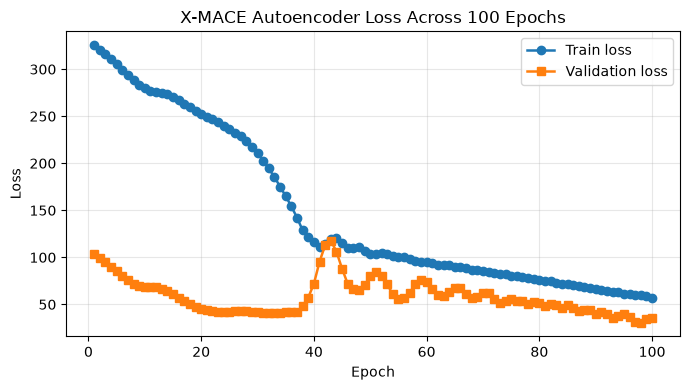

In [19]:
# Matplotlib cool library to plot shit
import matplotlib.pyplot as plt

# history is a list of dictionaries, one dictionary per epoch.
# Each dictionary was appended by the training cell above.
epochs = [row["epoch"] for row in history]
train_losses = [row["train_loss"] for row in history]
valid_losses = [row["valid_loss"] for row in history]

# Plot the training curve and validation curve on the same axes.
# A falling curve means the model is reducing the loss for that split.
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(epochs, train_losses, marker="o", linewidth=1.8, label="Train loss")
ax.plot(epochs, valid_losses, marker="s", linewidth=1.8, label="Validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(f"X-MACE Autoencoder Loss Across {MAX_EPOCHS} Epochs")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

# Save the plot in the RUN_DIR path 
# You can edit the name of the png file to be the paramters you used
# Can save and see how the training looks like for different parameters 
# Eg if you maybe increase latent space from 4 to 8 etc how does the loss 
# curve look like
GRAPH_DIR = os.path.join(RUN_DIR, "graphs")
os.makedirs(GRAPH_DIR, exist_ok=True)
LOSS_PLOT_PATH = os.path.join(GRAPH_DIR, "loss_curve.png")
#fig.savefig(LOSS_PLOT_PATH, dpi=150)
plt.show()


NOTE: the loss function is not normalised I think, so quite expected that the validation loss will be smaller. But the shape of this loss is whats important to note. After about 10 epochs you can see here that the model pretty much learned the data already and so training can stop. But again because this dataset is really small and the paramters were intentionally kept low. 

## 5. Save Checkpoints Inside The Root Directory

The full model file can be loaded with `torch.load(..., weights_only=False)`. The state checkpoint plus JSON config is usually easier to inspect and version.

In [26]:
# Save paths live under RUN_DIR, which itself lives under ROOT_PATH.
STATE_PATH = os.path.join(RUN_DIR, "autoencoder_minimum_state.pt")
FULL_MODEL_PATH = os.path.join(RUN_DIR, "autoencoder_minimum_full.model")
CONFIG_PATH = os.path.join(RUN_DIR, "autoencoder_minimum_config.json")

# This JSON-compatible metadata is enough to understand how the tiny model was built.
config_json = {
    "model_class": "AutoencoderExcitedMACE",
    "n_geometries": N_GEOMETRIES,
    "max_epochs": MAX_EPOCHS,
    "r_max": R_MAX,
    "batch_size": BATCH_SIZE,
    "atomic_numbers": [int(z) for z in z_table.zs],
    "atomic_energies": atomic_energies.tolist(),
    "avg_num_neighbors": float(avg_num_neighbors),
    "history": history,
}

# Save trainable weights and metadata in a research-friendly checkpoint.
torch.save({"state_dict": model.state_dict(), **config_json}, STATE_PATH)

# Save the full model object too. This is convenient, but more fragile across code changes.
torch.save(model.to("cpu"), FULL_MODEL_PATH)
model.to(DEVICE)

# Save readable metadata next to the checkpoint.
with open(CONFIG_PATH, "w") as f:
    json.dump(config_json, f, indent=2)

print("State checkpoint:", STATE_PATH)
print("Full model:", FULL_MODEL_PATH)
print("Config JSON:", CONFIG_PATH)

State checkpoint: /Users/naythanyeo/Documents/Research/2026/MLIP/Notebooks/trial_run_output/autoencoder_minimum_state.pt
Full model: /Users/naythanyeo/Documents/Research/2026/MLIP/Notebooks/trial_run_output/autoencoder_minimum_full.model
Config JSON: /Users/naythanyeo/Documents/Research/2026/MLIP/Notebooks/trial_run_output/autoencoder_minimum_config.json


## 6. Compare Predicted And Reference Energies

This evaluates one validation batch and prints predicted energies next to the true reference energies. With only 50 geometries, this is just a test to make sure it runs, not a useful scientific model.

In [27]:
model.eval()

# Take one validation batch. With BATCH_SIZE=2, this contains two geometries.
sample_batch = next(iter(valid_loader)).to(DEVICE)

# Energy-only evaluation does not need forces, so compute_force=False keeps this quick.
sample_output = model(
    sample_batch.to_dict(),
    training=False,
    compute_force=False,
    compute_virials=False,
    compute_stress=False,
)

# Convert tensors to NumPy arrays for readable printing.
predicted_energy = sample_output["energy"].detach().cpu().numpy()
reference_energy = sample_batch["energy"].detach().cpu().numpy()
energy_error = predicted_energy - reference_energy

# Make array printing compact but still readable.
np.set_printoptions(precision=6, suppress=True)

print("Predicted energies, eV:")
print(predicted_energy)

print("\nReference energies, eV:")
print(reference_energy)

print("\nPrediction - reference, eV:")
print(energy_error)

print("\nMAE per state, eV:", np.mean(np.abs(energy_error), axis=0))
print("Overall energy MAE, eV:", float(np.mean(np.abs(energy_error))))

Predicted energies, eV:
[[-23090.566 -23090.457 -23090.416 -23090.38 ]
 [-23090.557 -23090.451 -23090.402 -23090.371]
 [-23090.57  -23090.459 -23090.42  -23090.383]
 [-23090.562 -23090.455 -23090.41  -23090.377]]

Reference energies, eV:
[[-23089.217 -23089.643 -23089.629 -23089.232]
 [-23090.729 -23090.463 -23090.77  -23090.701]
 [-23091.32  -23091.066 -23091.387 -23091.102]
 [-23090.084 -23089.951 -23090.56  -23090.2  ]]

Prediction - reference, eV:
[[-1.349609 -0.814453 -0.787109 -1.148438]
 [ 0.171875  0.011719  0.367188  0.330078]
 [ 0.75      0.607422  0.966797  0.71875 ]
 [-0.478516 -0.503906  0.150391 -0.177734]]

MAE per state, eV: [0.6875   0.484375 0.567871 0.59375 ]
Overall energy MAE, eV: 0.5833740234375
